## Classement MNIST - CNN - 

### Etape 1 : Import des blibliothÃ¨ques python

In [7]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import sys
from importlib import reload

print("Python:", sys.executable)
print("Keras:", keras.__version__, "| backend:", keras.backend.backend())
print("TensorFlow:", tf.__version__)

fit_verbosity = 1

Python: c:\Users\Bryce\OneDrive\10 - Autres cours & python\01 - Projets python\CNN\.venv\Scripts\python.exe
Keras: 3.14.1 | backend: tensorflow
TensorFlow: 2.21.0


### Etape 2 : Collecter les donnÃ©es

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
#on obtient des images en niveau de gris 28x28
#(60000, 28, 28) --> (nombre_images, hauteur, largeur, nombre_canaux) , ici 1 canal 
#y_test  :  (10000,) -> etiquettes attendues
x_train = x_train.reshape(-1,28,28,1)
x_test  = x_test.reshape(-1,28,28,1)


print("x_train : ",x_train.shape)
print("y_train : ",y_train.shape)
print("x_test  : ",x_test.shape)
print("y_test  : ",y_test.shape)

x_train :  (60000, 28, 28, 1)
y_train :  (60000,)
x_test  :  (10000, 28, 28, 1)
y_test  :  (10000,)


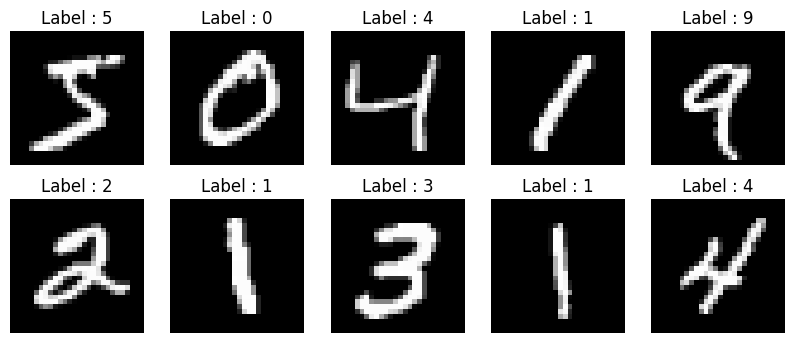

In [11]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label : {y_train[i]}")
    plt.axis("off")

plt.show()


### Etape 3 PrÃ©parer les donnÃ©es

In [10]:
print('Before normalization : Min={}, max={}'.format(x_train.min(),x_train.max()))

xmax=x_train.max()
x_train = x_train / xmax
x_test  = x_test  / xmax

print('After normalization  : Min={}, max={}'.format(x_train.min(),x_train.max()))

Before normalization : Min=0, max=255
After normalization  : Min=0.0, max=1.0


### Etape 4 : CrÃ©er le modÃ¨le

In [14]:
model = keras.models.Sequential()

model.add(keras.layers.Input(shape=(28, 28, 1)))

model.add(keras.layers.Conv2D(8, (3, 3), activation="relu"))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.Conv2D(16, (3, 3), activation="relu"))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(10, activation="softmax"))

model.summary()


Model: "sequential_2"

Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€â€œ
Ã¢â€Æ’ Layer (type)                    Ã¢â€Æ’ Output Shape           Ã¢â€Æ’       Param # Ã¢â€Æ’
Ã¢â€Â¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â©
Ã¢â€â€š conv2d (Conv2D)                 Ã¢â€â€š (None, 26, 26, 8)      Ã¢â€â€š            80 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š max_pooling2d (MaxPooling2D)    Ã¢â€â€š (None, 13, 13, 8)      Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š dropout (Dropout)               Ã¢â€â€š (None, 13, 13, 8)      Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š conv2d_1 (Conv2D)               Ã¢â€â€š (None, 11, 11, 16)     Ã¢â€â€š         1,168 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â

 Total params: 42,358 (165.46 KB)

 Trainable params: 42,358 (165.46 KB)

 Non-trainable params: 0 (0.00 B)

### Etape 5:  Entrainer le modÃ¨le

In [17]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

batch_size = 512
epochs = 16

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=fit_verbosity,
    validation_data=(x_test, y_test)
)


Epoch 1/16
118/118 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 3s 16ms/step - accuracy: 0.6372 - loss: 1.0917 - val_accuracy: 0.9246 - val_loss: 0.2807
Epoch 2/16
118/118 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 2s 14ms/step - accuracy: 0.8702 - loss: 0.4148 - val_accuracy: 0.9533 - val_loss: 0.1621
Epoch 3/16
118/118 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 2s 14ms/step - accuracy: 0.9086 - loss: 0.2984 - val_accuracy: 0.9650 - val_loss: 0.1177
Epoch 4/16
118/118 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 2s 15ms/step - accuracy: 0.9280 - loss: 0.2393 - val_accuracy: 0.9697 - val_loss: 0.0973
Epoch 5/16
118/118 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 2s 15ms/step - accuracy: 0.9367 - loss: 0.2103 - val_accuracy: 0.9734 - val_loss: 0.0854
Epoch 6/16
118/118 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 2s 14ms/step - accuracy: 0.9435 - loss: 0.1866 - val_accuracy: 0.9766 - val

### Etape 6 : Evaluer le modÃ¨le

Test loss     : 0.0406
Test accuracy : 0.9864


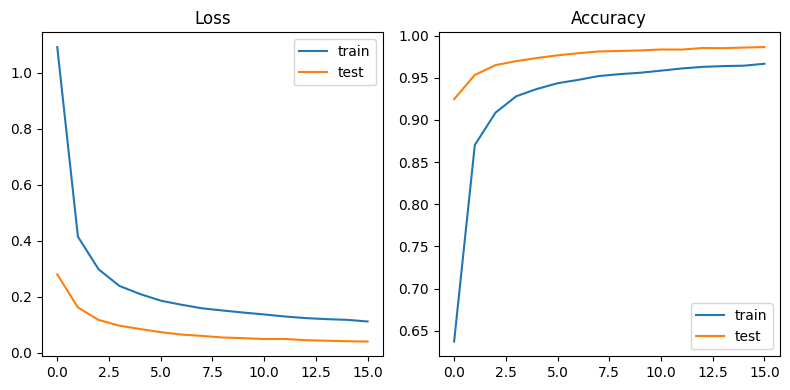

In [19]:
score = model.evaluate(x_test, y_test, verbose=0)

print(f'Test loss     : {score[0]:4.4f}')
print(f'Test accuracy : {score[1]:4.4f}')

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Etape 7 : Visualiser les prédictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


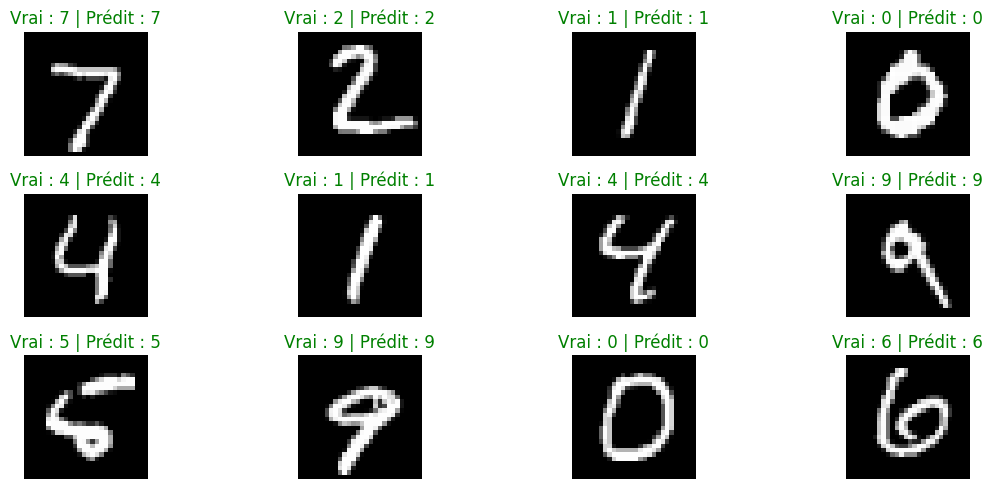

In [22]:
y_proba = model.predict(x_test)
y_pred = np.argmax(y_proba, axis=1)

plt.figure(figsize=(12, 5))

for i in range(12):
    couleur = "green" if y_pred[i] == y_test[i] else "red"
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Vrai : {y_test[i]} | Prédit : {y_pred[i]}", color=couleur)
    plt.axis("off")

plt.tight_layout()
plt.show()


Nombre d erreurs : 136


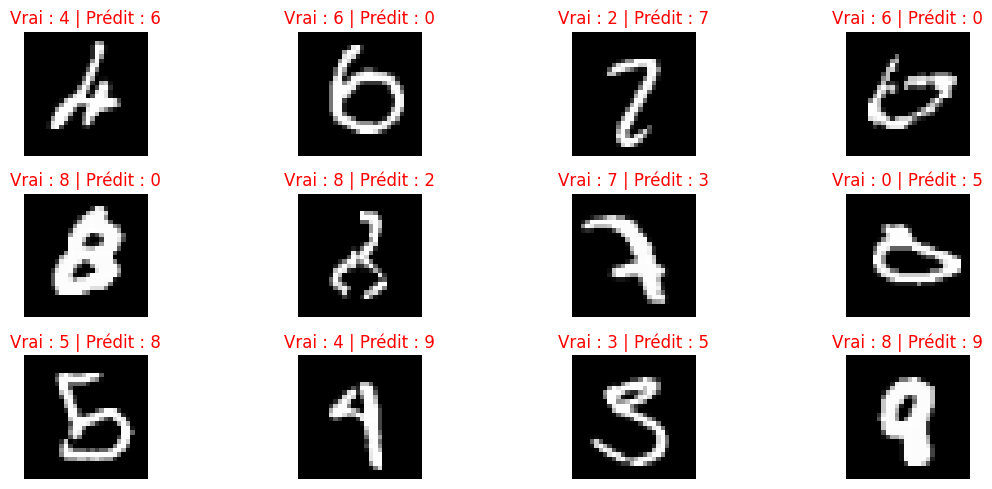

In [23]:
erreurs = np.where(y_pred != y_test)[0]
nb_erreurs = min(12, len(erreurs))

print("Nombre d erreurs :", len(erreurs))

plt.figure(figsize=(12, 5))

for i in range(nb_erreurs):
    index = erreurs[i]
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[index].reshape(28, 28), cmap="gray")
    plt.title(f"Vrai : {y_test[index]} | Prédit : {y_pred[index]}", color="red")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Etape 8 : Matrice de confusion

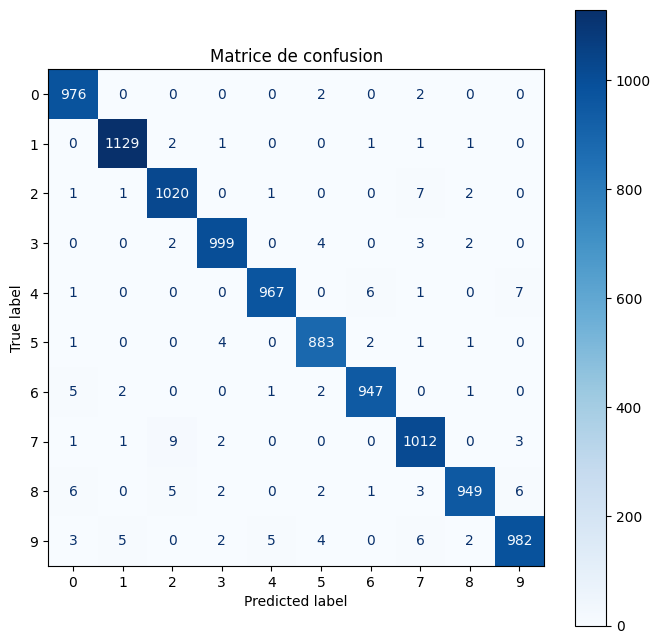

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matrice = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))
affichage = ConfusionMatrixDisplay(confusion_matrix=matrice, display_labels=range(10))
affichage.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Matrice de confusion")
plt.show()


Meilleure epoch selon val_loss : 16
Train accuracy finale : 0.9666
Test accuracy finale  : 0.9864
Ecart accuracy        : -0.0198
Train loss finale     : 0.1123
Test loss finale      : 0.0406
Ecart loss            : -0.0716
Conclusion : pas de surapprentissage evident.


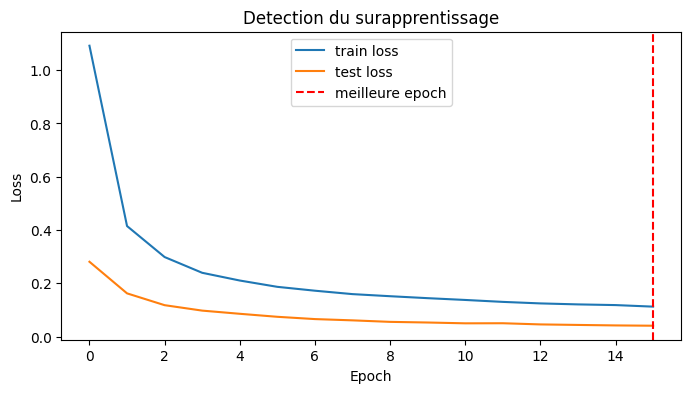

In [25]:
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

best_epoch = np.argmin(val_loss) + 1
ecart_acc = train_acc[-1] - val_acc[-1]
ecart_loss = val_loss[-1] - train_loss[-1]

print("Meilleure epoch selon val_loss :", best_epoch)
print(f"Train accuracy finale : {train_acc[-1]:.4f}")
print(f"Test accuracy finale  : {val_acc[-1]:.4f}")
print(f"Ecart accuracy        : {ecart_acc:.4f}")
print(f"Train loss finale     : {train_loss[-1]:.4f}")
print(f"Test loss finale      : {val_loss[-1]:.4f}")
print(f"Ecart loss            : {ecart_loss:.4f}")

if ecart_acc > 0.03 and ecart_loss > 0.02:
    print("Conclusion : surapprentissage probable.")
elif ecart_acc > 0.02 or ecart_loss > 0.05:
    print("Conclusion : leger surapprentissage possible, a surveiller.")
else:
    print("Conclusion : pas de surapprentissage evident.")

plt.figure(figsize=(8, 4))
plt.plot(train_loss, label="train loss")
plt.plot(val_loss, label="test loss")
plt.axvline(best_epoch - 1, color="red", linestyle="--", label="meilleure epoch")
plt.title("Detection du surapprentissage")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
